In [1]:
!pip install Sastrawi
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from wordcloud import WordCloud
from collections import Counter

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# =====================
# LOAD DATASET
# =====================

df = pd.read_csv("/content/drive/MyDrive/Text Mining/indonesian_news_dataset.csv", on_bad_lines='skip', engine='python')

print("Kolom dataset:", df.columns.tolist())
print("Jumlah baris:", len(df))
print("Jumlah kolom:", len(df.columns))

Kolom dataset: ['id', 'source', 'title', 'image', 'url', 'content', 'date', 'embedding', 'created_at', 'updated_at', 'summary']
Jumlah baris: 32735
Jumlah kolom: 11


In [5]:
# =====================
# EKSPLORASI DATA ANALYSIS
# =====================

# Cek missing value
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
id              0
source          0
title           0
image         160
url             0
content       441
date            0
embedding       0
created_at      0
updated_at      0
summary        10
dtype: int64


In [6]:
# Hapus baris dengan konten kosong
df.dropna(subset=['content'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nJumlah data setelah hapus missing: {len(df)}")


Jumlah data setelah hapus missing: 32294



--- Statistik Panjang Teks (kata) ---
count    32294.000000
mean       319.075184
std        163.498503
min         11.000000
25%        215.000000
50%        290.000000
75%        387.000000
max       1895.000000
Name: panjang_teks, dtype: float64


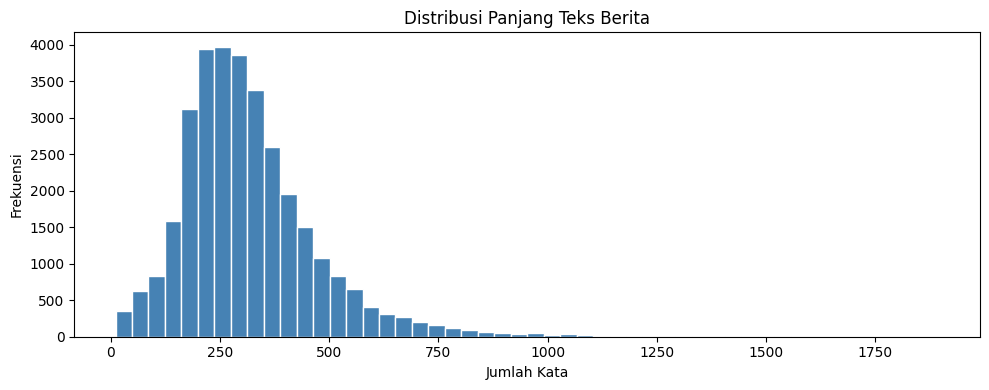

In [7]:
# Distribusi panjang teks
df['panjang_teks'] = df['content'].apply(lambda x: len(str(x).split()))

print("\n--- Statistik Panjang Teks (kata) ---")
print(df['panjang_teks'].describe())

# Visualisasi distribusi panjang teks
plt.figure(figsize=(10, 4))
plt.hist(df['panjang_teks'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.title("Distribusi Panjang Teks Berita")
plt.tight_layout()
plt.show()

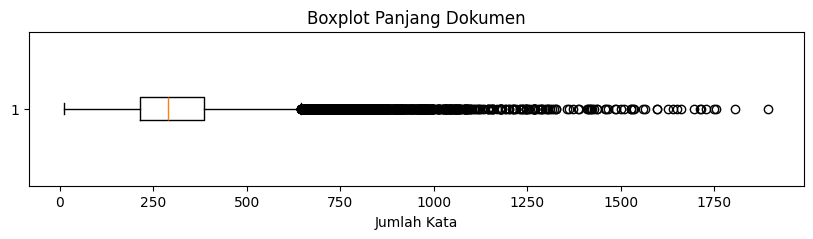

In [8]:
# =====================
# BOXPLOT PANJANG DOKUMEN
# =====================

plt.figure(figsize=(10,2))

plt.boxplot(
    df["panjang_teks"],
    vert=False
)

plt.title("Boxplot Panjang Dokumen")
plt.xlabel("Jumlah Kata")
plt.show()

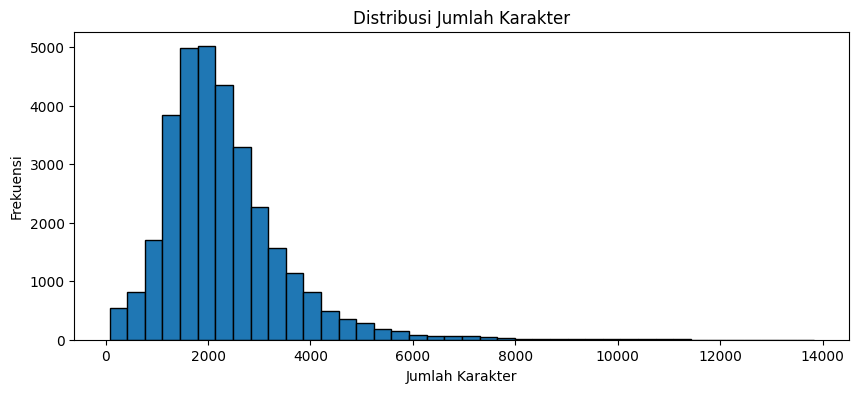

In [9]:
# =====================
# DISTRIBUSI JUMLAH KARAKTER
# =====================

df["jumlah_karakter"] = df["content"].astype(str).apply(len)

plt.figure(figsize=(10,4))
plt.hist(df["jumlah_karakter"], bins=40, edgecolor="black")
plt.title("Distribusi Jumlah Karakter")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")
plt.show()

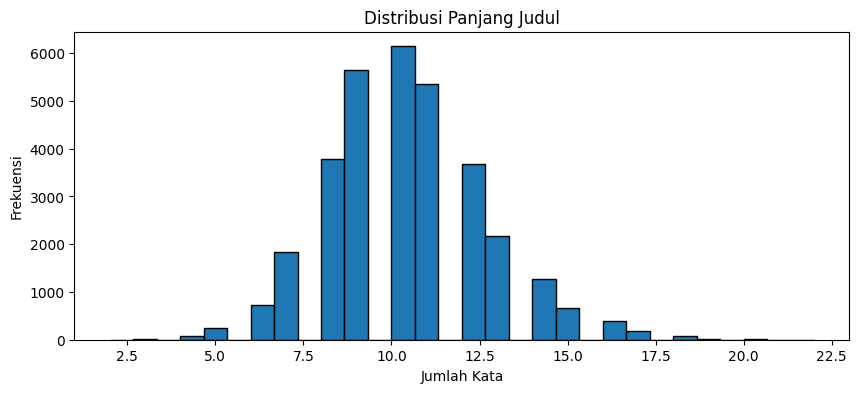

count    32294.000000
mean        10.280733
std          2.261460
min          2.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         22.000000
Name: judul_length, dtype: float64


In [10]:
# =====================
# DISTRIBUSI PANJANG JUDUL
# =====================

df["judul_length"] = df["title"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10,4))
plt.hist(df["judul_length"], bins=30, edgecolor="black")
plt.title("Distribusi Panjang Judul")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

print(df["judul_length"].describe())

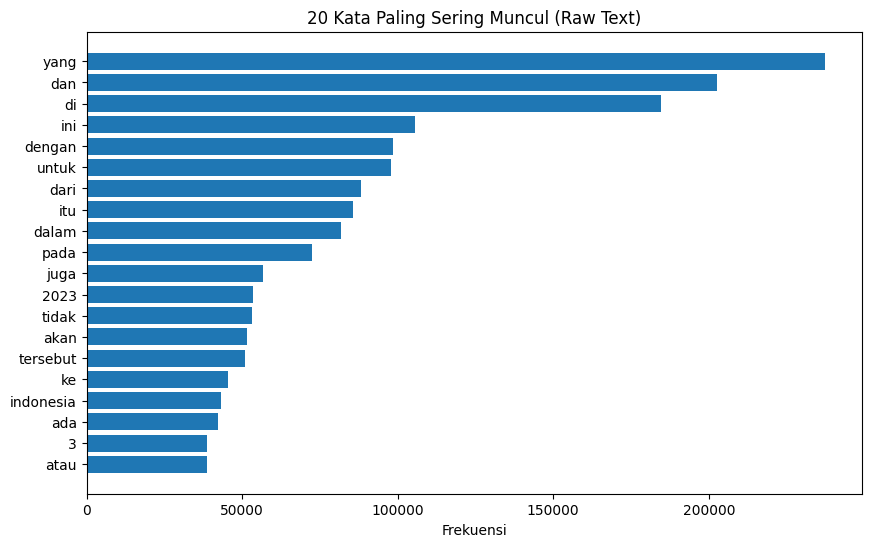

In [11]:
# =====================
# TOP WORD SEBELUM PREPROCESSING
# =====================

all_words = " ".join(df["content"].astype(str).tolist()).lower()

all_words = re.sub(r'[^\w\s]', ' ', all_words)

word_counts = Counter(all_words.split())

top20 = word_counts.most_common(20)

words = [x[0] for x in top20]
counts = [x[1] for x in top20]

plt.figure(figsize=(10,6))
plt.barh(words[::-1], counts[::-1])
plt.title("20 Kata Paling Sering Muncul (Raw Text)")
plt.xlabel("Frekuensi")
plt.show()

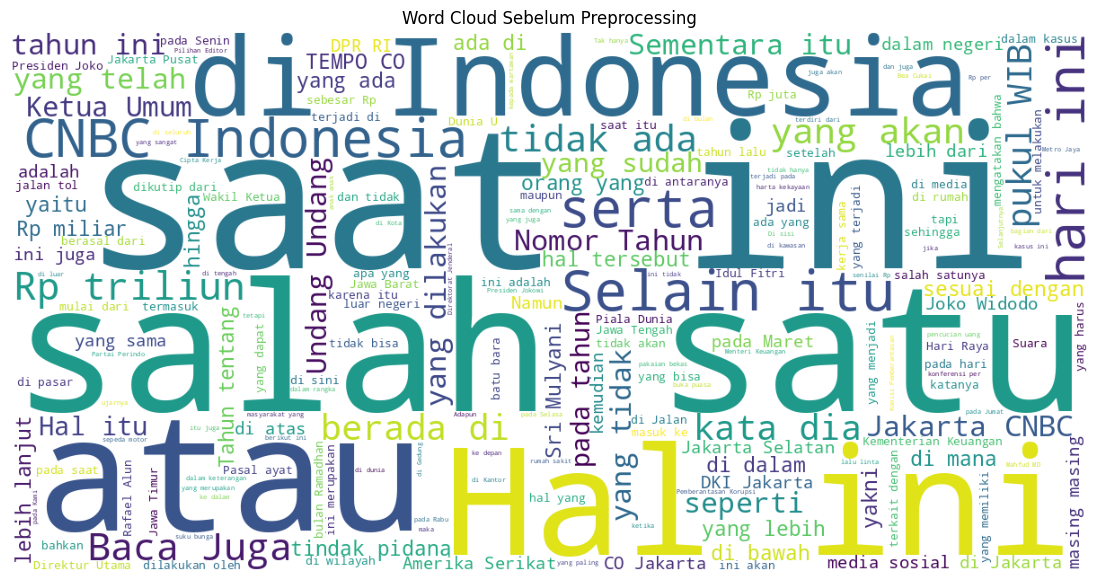

In [12]:
# =====================
# WORD CLOUD RAW TEXT
# =====================

text = " ".join(df["content"].astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud Sebelum Preprocessing")
plt.show()

In [ ]:
# =====================
# PREPROCESSING
# =====================

# Ambil kolom teks
texts = df['content'].astype(str)

# Stemmer & Stopword
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

def preprocess_text(text):

    # Case Folding
    text = text.lower()

    # Remove URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove Punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove Extra Spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenisasi
    words = text.split()

    # Hapus angka murni saja
    words = [w for w in words if not w.isdigit()]

    custom_stopwords = {
        'indonesia',
        'tahun',
        'orang',
        'kata',
        'menjadi',
        'lebih',
        'tersebut',
        'satu',
        'jakarta',
        'hari',
        'bulan'
    }

    stopwords.update(custom_stopwords)

    # Stopword Removal
    words = [w for w in words if w not in stopwords]

    return " ".join(words)

print("Preprocessing dimulai...")
cleaned_texts = texts.apply(preprocess_text)
df['cleaned'] = cleaned_texts

print("Preprocessing selesai!")

Preprocessing dimulai...
Preprocessing selesai!


In [ ]:
# Tampilkan contoh sebelum vs sesudah
print("\n--- Contoh Hasil Preprocessing ---")
for i in range(2):
    print(f"\n[ASLI]\n{texts[i][:200]}")
    print(f"[BERSIH]\n{cleaned_texts[i][:200]}")


--- Contoh Hasil Preprocessing ---

[ASLI]
TEMPO.CO, Jakarta - Anggota Komisi VII DPR RI Rofik Hananto menyayangkan terjadinya insiden kebakaran yang disebabkan oleh bocornya depo Plumpang, Jakarta Utara, pada Jumat, 3 Maret 2023."Turut berbel
[BERSIH]
tempo co anggota komisi vii dpr ri rofik hananto menyayangkan terjadinya insiden kebakaran disebabkan bocornya depo plumpang utara jumat maret turut berbela sungkawa masyarakat sipil terdampak daerah 

[ASLI]
TEMPO.CO, Jakarta - Presiden Joko Widodo atau Jokowi memerintahkan Wakil Presiden Ma'ruf Amin untuk meninjau langsung lokasi kebakaran depo Pertamina di Plumpang, Jakarta Utara. Kebakaran besar di lok
[BERSIH]
tempo co presiden joko widodo jokowi memerintahkan wakil presiden ma ruf amin meninjau langsung lokasi kebakaran depo pertamina plumpang utara kebakaran besar lokasi terjadi jumat malam maret mengakib


In [ ]:
# =====================
# TF-IDF VECTORIZATION
# =====================

vectorizer = TfidfVectorizer(
    max_features=50000,
    max_df=0.8,
    min_df=10,
    ngram_range=(1, 2)   # unigram + bigram untuk konteks lebih kaya
)

X = vectorizer.fit_transform(cleaned_texts)

print("Shape TF-IDF matrix:", X.shape)
print(f"Jumlah fitur (term): {X.shape[1]}")
print(f"Jumlah dokumen     : {X.shape[0]}")

Shape TF-IDF matrix: (32294, 50000)
Jumlah fitur (term): 50000
Jumlah dokumen     : 32294


In [ ]:
from sklearn.decomposition import TruncatedSVD

In [ ]:
for n in [100, 300, 500, 1000]:

    svd = TruncatedSVD(
        n_components=n,
        random_state=42
    )

    X_svd = svd.fit_transform(X)

    print(
        f"{n} komponen -> "
        f"{svd.explained_variance_ratio_.sum():.4f}"
    )

100 komponen -> 0.1834
300 komponen -> 0.3042
500 komponen -> 0.3740
1000 komponen -> 0.4840


In [ ]:
svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_svd = svd.fit_transform(X)

print(X_svd.shape)

(32294, 100)


K=2 | Inertia=5669.69 | Silhouette=0.2013
K=3 | Inertia=5540.71 | Silhouette=0.1291
K=4 | Inertia=5382.61 | Silhouette=0.1171
K=5 | Inertia=5297.73 | Silhouette=0.1273
K=6 | Inertia=5228.71 | Silhouette=0.0458
K=7 | Inertia=5094.77 | Silhouette=0.0540
K=8 | Inertia=5003.88 | Silhouette=0.1379
K=9 | Inertia=4919.33 | Silhouette=0.0704
K=10 | Inertia=4833.49 | Silhouette=0.0598
K=11 | Inertia=4737.83 | Silhouette=0.0704
K=12 | Inertia=4666.43 | Silhouette=0.0753
K=13 | Inertia=4587.74 | Silhouette=0.0931
K=14 | Inertia=4514.24 | Silhouette=0.0738
K=15 | Inertia=4452.83 | Silhouette=0.0805

K terbaik berdasarkan Silhouette Score = 2
Silhouette tertinggi = 0.2013


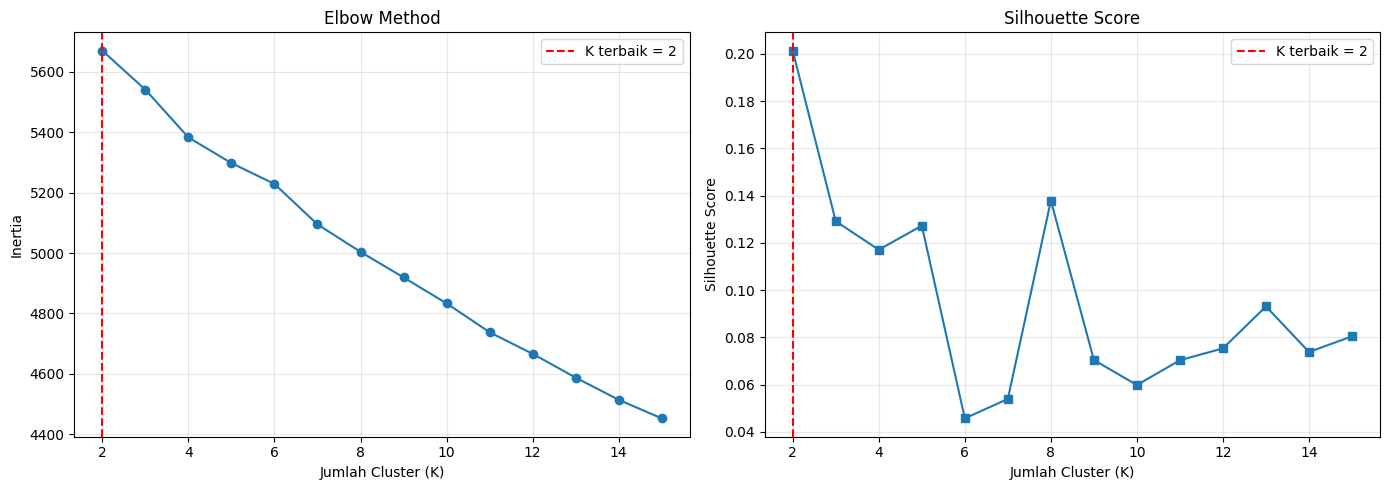

In [ ]:
# =====================
# MENENTUKAN K OPTIMAL
# ELBOW + SILHOUETTE
# =====================

inertia = []
silhouette_scores = []

K = range(2, 16)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_svd)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(
        X_svd,
        labels,
        sample_size=1000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(
        f"K={k} | "
        f"Inertia={kmeans.inertia_:.2f} | "
        f"Silhouette={score:.4f}"
    )

# Cari K terbaik berdasarkan Silhouette
best_k = K[np.argmax(silhouette_scores)]

print("\n" + "="*50)
print(f"K terbaik berdasarkan Silhouette Score = {best_k}")
print(f"Silhouette tertinggi = {max(silhouette_scores):.4f}")
print("="*50)

# =====================
# VISUALISASI
# =====================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K, inertia, marker='o')
axes[0].axvline(
    x=best_k,
    color='red',
    linestyle='--',
    label=f'K terbaik = {best_k}'
)
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Jumlah Cluster (K)")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(K, silhouette_scores, marker='s')
axes[1].axvline(
    x=best_k,
    color='red',
    linestyle='--',
    label=f'K terbaik = {best_k}'
)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Jumlah Cluster (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# =====================
# FUNGSI ANALISIS CLUSTER
# =====================

from sklearn.cluster import KMeans

def analyze_cluster(k):

    print("="*60)
    print(f"ANALISIS K = {k}")
    print("="*60)

    # Clustering
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_svd)

    # Simpan ke dataframe sementara
    temp_df = df.copy()
    temp_df['cluster'] = labels

    # Distribusi cluster
    print("\nDistribusi Cluster:")
    print(temp_df['cluster'].value_counts().sort_index())

    # Keyword
    terms = vectorizer.get_feature_names_out()

    original_centroids = svd.inverse_transform(
        kmeans.cluster_centers_
    )

    print("\nTop Keywords:")

    for i in range(k):

        center = original_centroids[i]

        top_idx = center.argsort()[-15:][::-1]

        top_words = [terms[idx] for idx in top_idx]

        print(f"\nCluster {i}:")
        print(", ".join(top_words))

    # Sample berita
    print("\n\nSample Berita:")

    for i in range(k):

        print("\n" + "="*50)
        print(f"CLUSTER {i}")
        print("="*50)

        samples = temp_df[
            temp_df['cluster'] == i
        ]['content'].head(3)

        for j, article in enumerate(samples):

            print(f"\nBerita {j+1}:")
            print(article[:250])

         EVALUASI CLUSTERING
  Silhouette Score     : 0.1551  (makin tinggi makin baik, maks 1)
  Davies-Bouldin Index : 2.3101  (makin rendah makin baik, min 0)

--- Distribusi Dokumen per Cluster ---
cluster
0      338
1      669
2     2554
3      382
4     1734
5    23670
6     2527
7      420


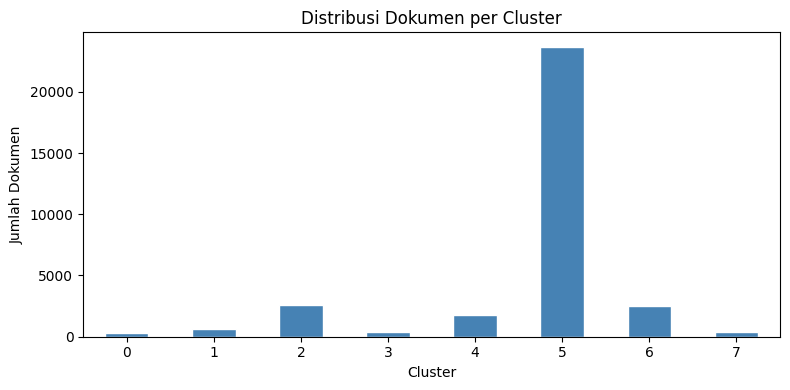

In [ ]:
# =====================
# K-MEANS CLUSTERING
# =====================

optimal_k = 8

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

labels = kmeans.fit_predict(X_svd)

df['cluster'] = labels

# =====================
# EVALUASI CLUSTER
# =====================

sil_score = silhouette_score(X_svd, kmeans.labels_)
db_score = davies_bouldin_score(X_svd, kmeans.labels_)

print("="*45)
print("         EVALUASI CLUSTERING")
print("="*45)
print(f"  Silhouette Score     : {sil_score:.4f}  (makin tinggi makin baik, maks 1)")
print(f"  Davies-Bouldin Index : {db_score:.4f}  (makin rendah makin baik, min 0)")
print("="*45)

# Distribusi dokumen per cluster
dist = df['cluster'].value_counts().sort_index()
print("\n--- Distribusi Dokumen per Cluster ---")
print(dist.to_string())

# Visualisasi distribusi
plt.figure(figsize=(8, 4))
dist.plot(kind='bar', color='steelblue', edgecolor='white')
plt.xlabel("Cluster")
plt.ylabel("Jumlah Dokumen")
plt.title("Distribusi Dokumen per Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# =====================
# TOP KEYWORDS TIAP CLUSTER
# =====================

terms = vectorizer.get_feature_names_out()

# Kembalikan centroid dari ruang SVD ke ruang TF-IDF
original_centroids = svd.inverse_transform(
    kmeans.cluster_centers_
)

print("Top 15 Keywords per Cluster:\n")

for i in range(optimal_k):

    center = original_centroids[i]

    top_indices = center.argsort()[-15:][::-1]

    top_words = [terms[idx] for idx in top_indices]

    print(f"Cluster {i}: {', '.join(top_words)}")
    print()

Top 15 Keywords per Cluster:

Cluster 0: thr, tunjangan, pekerja, gaji, raya, pekerja buruh, perusahaan, pns, buruh, keagamaan, tunjangan raya, ida, kerja, asn, masa kerja

Cluster 1: mahfud, transaksi, ppatk, triliun, kemenkeu, keuangan, sri, rp triliun, mulyani, sri mulyani, rp, ivan, tppu, mencurigakan, md

Cluster 2: partai, koalisi, perindo, israel, prabowo, jokowi, pemilu, ketua, presiden, anies, piala dunia, piala, politik, ganjar, ketua umum

Cluster 3: kpk, endar, firli, dewas, direktur penyelidikan, penyelidikan, surat, priantoro, endar priantoro, kapolri, bahuri, firli bahuri, polri, pimpinan, brigjen

Cluster 4: kpk, rafael, korupsi, harta, ali, kasus, tersangka, rafael alun, alun, dugaan, pajak, uang, kekayaan, miliar, pemeriksaan

Cluster 5: korban, masyarakat, anak, pelaku, melakukan, pemerintah, negara, kota, hingga, mengatakan, jalan, rumah, dilakukan, warga, rp

Cluster 6: saham, bank, persen, as, triliun, harga, sebesar, miliar, indeks, pasar, rp, ihsg, perdagangan, 

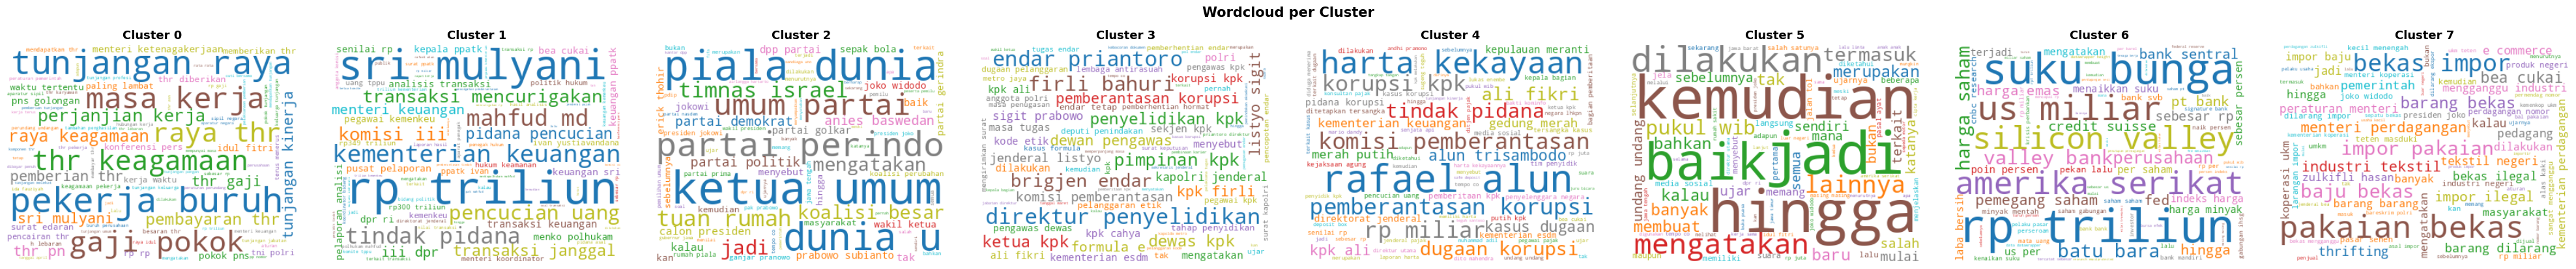

In [ ]:
# =====================
# WORDCLOUD PER CLUSTER
# =====================

fig, axes = plt.subplots(1, optimal_k, figsize=(5 * optimal_k, 4))

for i in range(optimal_k):
    # Gabungkan semua teks di cluster ini
    cluster_text = " ".join(df[df['cluster'] == i]['cleaned'].values)

    wc = WordCloud(
        width=400,
        height=300,
        background_color='white',
        max_words=80,
        colormap='tab10',
        random_state=42
    ).generate(cluster_text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f"Cluster {i}", fontsize=13, fontweight='bold')

plt.suptitle("Wordcloud per Cluster", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
clusters = kmeans.fit_predict(X_svd)

In [ ]:
import numpy as np

for c in range(optimal_k):

    idx = np.where(
        clusters == c
    )[0]

    center = kmeans.cluster_centers_[c]

    distances = np.linalg.norm(
        X_svd[idx] - center,
        axis=1
    )

    closest = idx[
        np.argsort(distances)[:10]
    ]

    print(f"\nCLUSTER {c}")

    for i in closest:
        print(
            df.iloc[i]["title"]
        )


CLUSTER 0
Ini Cara Menghitung THR Masa Kerja 10 Tahun
Menguak Sejarah THR di Indonesia
Sudah Dinanti-nanti, Eh Ternyata Hanya Rekan (THR)
Sultan ke Pengusaha: THR Jangan Dicicil
Bertemu Menaker, Pengusaha Janji Tak Cicil THR Lebaran
THR Pegawai Swasta Cair Tanggal Segini, Langsung Cek Rekening
Sabar Ya! Kepastian Tanggal THR Cair Diumumkan Hari Ini
Rp 70 Miliar THR ASN Pemda DIY Dicairkan
Menpan RB Sebut THR PNS Cair H-5 Lebaran
Disnakertrans DIY Buka Posko Aduan THR 

CLUSTER 1
Soal Data Transaksi Rp 349 T, Mahfud MD Pastikan Tidak Beda dengan Sri Mulyani: Penyajiannya Beda
Tegaskan Data Rp349 Triliun Tak Ada Perbedaan, Ini Penjelasan Mahfud MD
Mahfud MD soal Rp 300 T di Kemenkeu: Kalau Bukan Korupsi, Terus Apa?
Mahfud, Sri Mulyani, PPATK, Bahas Polemik Rp 349 Triliun, Begini Hasilnya
Data PPATK Soal Transaksi Janggal Rp 300 T di Kemenkeu, Peneliti ICW: Saya Cenderung Percaya
Mahfud MD: Baru Sebagian 300 Laporan Transaksi Janggal Kemenkeu Diperiksa
Eks Kepala PPATK: Harusnya Transaks

## Subclustering

In [ ]:
# =====================
# SUBCLUSTERING CLUSTER 5
# =====================

cluster_besar = 5

df_sub = df[
    df["cluster"] == cluster_besar
].copy()

print(
    f"Jumlah dokumen: {len(df_sub)}"
)

Jumlah dokumen: 23670


In [ ]:
vectorizer_sub = TfidfVectorizer(
    max_features=5000
)

X_sub = vectorizer_sub.fit_transform(
    df_sub["cleaned"]
)

In [ ]:
svd_sub = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_sub_svd = svd_sub.fit_transform(
    X_sub
)

In [ ]:
for k in range(2,8):

    kmeans_sub = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_sub = kmeans_sub.fit_predict(
        X_sub_svd
    )

    score = silhouette_score(
        X_sub_svd,
        labels_sub,
        sample_size=1000,
        random_state=42
    )

    print(
        f"K={k} -> {score:.4f}"
    )

K=2 -> 0.0591
K=3 -> 0.0761
K=4 -> 0.0756
K=5 -> 0.0871
K=6 -> 0.0823
K=7 -> 0.0805


In [ ]:
sub_kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

df_sub["subcluster"] = sub_kmeans.fit_predict(
    X_sub_svd
)

In [ ]:
for c in sorted(
    df_sub["subcluster"].unique()
):

    print("\n")
    print("="*50)
    print(
        f"SUBCLUSTER {c}"
    )

    sample = (
        df_sub[
            df_sub["subcluster"] == c
        ]["title"]
        .sample(
            15,
            random_state=42
        )
    )

    for title in sample:
        print("-", title)



SUBCLUSTER 0
- 4 Tips Mengatur Keuangan saat Ramadhan agar Kantong Tetap Aman
- Tata Cara Sholat Idul Fitri Lengkap: Ketentuan, Niat, dan Sunah-Sunahnya
- Amalan Nuzulul Quran Sholat Tahajud, Begini Panduan Lengkapnya dari Niat hingga Bacaan Doa Setelahnya
- Bolehkah Sholat Tarawih 4 Rakaat Sekali Salam? Begini Penjelasan Buya Yahya
- Foto Bareng Jokowi dan Bapak-bapak, Pose Jempol Jan Ethes Mewakili Banget!
- Niat Sholat Tarawih Ramadhan Sendiri dan Berjamaah, Latin Lengkap dengan Artinya
- Pengamat Sarankan Pemprov DKI Terapkan WFH Sebagian Demi Hindari Macet di Bulan Ramadhan
- Hukum Mengerjakan Salat Tarawih di Bulan Ramadhan bagi Umat Muslim
- 4 Contoh Amalan Sunnah Muakkad bagi Umat Muslim
- Selama Ramadhan, Warga Tangsel Dilarang Sahur dan Bukber On The Road
- Cara Cegah Bau Mulut saat Puasa
- Kapan Idul Fitri 2023, Lebaran 1 Syawal 1444 Hijriah Jatuh Tanggal 21 atau 22 April?
- KH Cholil Nafis: Buka Puasa Bersama Momen Silaturahmi
- Menpan RB Tak Segan Sanksi ASN yang Gelar B

In [ ]:
# =====================
# SUBCLUSTER CLUSTER 5
# =====================

subcluster_labels = {
    0: "Sosial dan Keagamaan",
    1: "Pangan, Pertanian, dan Ketahanan Pangan",
    2: "Transportasi dan Mobilitas Mudik",
    3: "Pemerintahan, Kebijakan Publik, dan Isu Sosial",
    4: "Politik Internasional, Pertahanan, dan Olahraga Internasional",
    5: "Kriminalitas, Kecelakaan, dan Keamanan Publik",
    6: "Hukum, Peradilan, dan Regulasi Pemerintah"
}

for i in range(5):

    print("="*65)
    print(
        f"SUBCLUSTER {i} — "
        f"{subcluster_labels[i]}"
    )
    print("="*65)

    samples = (
        df_sub[
            df_sub["subcluster"] == i
        ]["content"]
        .head(3)
        .values
    )

    for j, article in enumerate(samples):

        print(f"\nBerita {j+1}:")
        print(article[:350])

    print()

SUBCLUSTER 0 — Sosial dan Keagamaan

Berita 1:
TEMPO.CO, Jakarta -Kantor Wilayah Kementerian Agama Provinsi Aceh menyiapkan lima alat teleskop untuk melakukan pengamatan rukyatul hilal 1 Ramadhan 1444 Hijriah/2023 Masehi di enam lokasi. Ketua Tim Falakiyah Kanwil Kemenag Aceh Alfirdaus Putra mengatakan rukyat dilakukan oleh tim Kemenag dan beberapa tim dari ormas Islam maupun dayah atau pesantr

Berita 2:
Jakarta, CNBCIndonesia - Pemerintah Arab Saudi membuat rangkaian peraturan terbaru terkait ibadah di masjid saat bulan suci Ramadhan. Hal ini tertuang dalam rilis terbaru Kementerian Urusan Agama Islam, ahir pekan kemarin. Dalam pernyataannya, ada beberapa peraturan terbaru. Seperti pengurangan pengeras suara masjid hingga pelarangan penyiaran shal

Berita 3:
PAI kelas 8 halaman 211 bagian B bermanfaat untuk bahan belajar di rumah. Latihan soal di halaman tersebut berdasarkan materi tentang puasa. Dengan demikian, kunci jawabannya juga bisa menjadi tuntunan dalam menjalankan ibadah pu

In [ ]:
import pandas as pd

pd.Series(
    kmeans_sub.labels_
).value_counts()

,count
3,15235
5,2328
4,1433
6,1417
2,1282
0,1252
1,723


### Cluster utama

In [ ]:
# =====================
# SAMPLE BERITA + INTERPRETASI CLUSTER
# =====================

# Kamus label
cluster_labels = {
    0: "Politik dan Pemerintahan",
    1: "Keuangan dan Tata Kelola Negara",
    2: "Hukum dan Pemberantasan Korupsi",
    3: "Olahraga dan Event Internasional",
    4: "Ekonomi dan Bisnis",
    5: "Sosial dan Kemasyarakatan",
    6: "Transportasi dan Infrastruktur",
    7: "Kriminalitas dan Keamanan Publik"
}

df['cluster_label'] = df['cluster'].map(cluster_labels)

for i in range(optimal_k):
    print("="*65)
    print(f"  CLUSTER {i} — {cluster_labels[i]}")
    print("="*65)

    samples = df[df['cluster'] == i]['content'].head(3).values
    for j, article in enumerate(samples):
        print(f"\n  Berita {j+1}:")
        print(f"  {article[:350]}")
    print()

  CLUSTER 0 — Politik dan Pemerintahan

  Berita 1:
  TEMPO.CO, Jakarta - Surat Edaran Menteri Ketenagakerjaan (Menaker) mengenai tunjangan hari raya atau THR untuk pekerja/buruh direncanakan terbit besok Senin, 27 Maret 2023. Kementerian Ketenagakerjaan atau Kemnaker menyatakan THR wajib dibayar secara penuh atau full.Intinya, sama dengan THR tahun tahun lalu bahwa THR untuk pekerja/buruh adalah bers

  Berita 2:
  JAKARTA - Menteri Keuangan (Menkeu) Sri Mulyani mengatakan bahwa Presiden Joko Widodo (Jokowi) segera mengumumkan pemberian tunjangan hari raya (THR) untuk Pegawai Negeri Sipil (PNS) dalam waktu dekat. "Bapak Presiden akan mengumumkan THR dalam beberapa minggu ke depan," ujarnya, dalam Konferensi Pers APBN KiTa di kantornya, Jakarta, Selasa (14/3/2

  Berita 3:
  Jakarta, CNBC Indonesia - Presiden Joko Widodo (Jokowi) akan mengumumkan perihal tunjangan hari raya (THR) bagi Aparatur Sipil Negara (ASN) dan TNI - Polri dalam waktu dekat, seiring karena semakin dekatnya Hari Ra

In [ ]:
import joblib

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(vectorizer_sub, "tfidf_sub.pkl")
joblib.dump(svd, "svd_model.pkl")
joblib.dump(svd_sub, "svd_sub.pkl")
joblib.dump(kmeans, "kmeans_main.pkl")
joblib.dump(sub_kmeans, "kmeans_sub.pkl")

print("Model berhasil disimpan")

Model berhasil disimpan


In [ ]:
joblib.dump(cluster_labels, "cluster_labels.pkl")
joblib.dump(subcluster_labels, "subcluster_labels.pkl")

['subcluster_labels.pkl']

In [ ]:
# =====================
# SAVE HASIL
# =====================

df.to_csv("hasil_clustering.csv", index=False)

print("Hasil clustering berhasil disimpan ke 'hasil_clustering.csv'")
print(f"\nRingkasan akhir:")
print(f"  Total dokumen  : {len(df)}")
print(f"  Jumlah cluster : {optimal_k}")
print(f"  Silhouette     : {sil_score:.4f}")
print(f"  Davies-Bouldin : {db_score:.4f}")
print(f"\nDistribusi cluster:")
print(df['cluster_label'].value_counts().to_string())

Hasil clustering berhasil disimpan ke 'hasil_clustering.csv'

Ringkasan akhir:
  Total dokumen  : 32294
  Jumlah cluster : 8
  Silhouette     : 0.1551
  Davies-Bouldin : 2.3101

Distribusi cluster:
cluster_label
Sosial dan Kemasyarakatan           23670
Hukum dan Pemberantasan Korupsi      2554
Transportasi dan Infrastruktur       2527
Ekonomi dan Bisnis                   1734
Keuangan dan Tata Kelola Negara       669
Kriminalitas dan Keamanan Publik      420
Olahraga dan Event Internasional      382
Politik dan Pemerintahan              338


In [ ]:
def predict_news(text):

    cleaned = preprocess_text(text)

    X_new = vectorizer.transform([cleaned])

    X_new_svd = svd.transform(X_new)

    cluster = kmeans.predict(X_new_svd)[0]

    label = cluster_labels[cluster]

    return cluster, label


### Contoh Prediksi

In [ ]:
berita = """
Pemerintah mengumumkan pembangunan jalan tol baru
untuk meningkatkan konektivitas antar wilayah.
"""

cluster, label = predict_news(berita)

print("Cluster:", cluster)
print("Kategori:", label)

Cluster: 6
Kategori: Transportasi dan Infrastruktur


In [ ]:
from google.colab import files
files.download("svd_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
for i in range(7):

    print(f"\nCLUSTER {i}")

    sample = df[
        df["cluster"] == i
    ]["title"].head(20)

    for j in sample:
        print("-", j)


CLUSTER 0
- Penundaan Pemilu 2024 Bisa Buat Jokowi 3 Periode? Ini Mereka yang Pernah Menyuarakan 
- PSHK Minta KY Dalami Motif Hakim PN Jakpus Memerintahkan Penundaan Pemilu
- Prabowo Subianto Gandeng Surya Paloh di Hambalang
- Soal Putusan Penundaan Pemilu, Wakil Ketua MPR Optimis KPU Bisa Menang Banding
- Sambut Surya Paloh, Prabowo Subianto: Kami Sepakat Saling Hormati Keputusan Politik Masing-Masing
- Isu Pemilu 2024 Ditunda Mencuat Lagi, Ini 5 Tokoh Pewacana Penundaan Pemilu, Luhut Sebut Big Data
- KPU Siapkan Memori Banding atas Putusan Penundaan Pemilu PN Jakarta Pusat
- Perludem Dukung Banding KPU atas Putusan Penundaan Pemilu PN Jakarta Pusat
- Sekjen PDIP:  Penundaan Pemilu Melawan Kekuatan Rakyat
- Putusan Penundaan Pemilu 2024, Tenaga Ahli KSP: Hak Hukum Partai Prima Harus Kita Hormati
- PSI Dukung KPU Ajukan Banding atas Putusan Penundaan Pemilu
- Putusan Penundaan Pemilu 2024, Partai Ummat: Jika Boleh, Dipercepat Saja
- Prabowo Subianto Tolak Pasangkan Sandiaga Uno denga